In [1]:
!pip install -q transformers peft accelerate datasets pandas

In [2]:
import json, random, re, warnings
import numpy as np, pandas as pd, torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MODEL_NAME = "HuggingFaceTB/SmolLM2-135M-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"
use_bf16 = device == "cuda" and torch.cuda.get_device_capability()[0] >= 8
DTYPE = torch.bfloat16 if use_bf16 else torch.float32
SYSTEM_PROMPT = "You are a helpful tutor for undergraduate students."
print("Device:", device, "| dtype:", DTYPE)

Device: cpu | dtype: torch.float32


In [3]:
# (question, definition, 3 key points, example, less-preferred answer)
raw = [
("What is photosynthesis?",
 "Photosynthesis is the process by which plants, algae and some bacteria convert light energy into chemical energy stored as glucose.",
 ["It happens in the chloroplasts, using the green pigment chlorophyll.", "Inputs are carbon dioxide, water and light; outputs are glucose and oxygen.", "It has two stages: the light-dependent reactions and the Calvin cycle."],
 "A leaf absorbing sunlight and releasing oxygen while building sugar for the plant.",
 "Photosynthesis is basically when plants do their thing with sunlight. It is a complicated process with many things involved, so it is hard to explain quickly."),
("State Newton's second law of motion.",
 "Newton's second law states that the acceleration of an object is directly proportional to the net force on it and inversely proportional to its mass (F = ma).",
 ["Force is measured in newtons, mass in kilograms, acceleration in m/s^2.", "A larger net force produces a larger acceleration.", "A larger mass produces a smaller acceleration for the same force."],
 "Pushing an empty shopping cart is easy to speed up, but a full cart needs a much bigger push for the same acceleration.",
 "Newton's second law, in the covariant formulation, equates the temporal derivative of the momentum four-vector with the net force under a Lagrangian-Hamiltonian manifold description, which generalizes the inertial frame postulate."),
("What is the difference between supervised and unsupervised learning?",
 "Supervised learning trains a model on labelled data, while unsupervised learning finds patterns in data that has no labels.",
 ["Supervised learning predicts a known target, such as a class or a number.", "Unsupervised learning discovers structure, such as clusters or hidden factors.", "Supervised learning needs labelled examples, which can be costly to collect."],
 "Spam detection from labelled emails is supervised; grouping customers by buying behaviour is unsupervised.",
 "Supervised is when you have labels and unsupervised is when you do not. They are both used in machine learning for different stuff."),
("What is overfitting in machine learning?",
 "Overfitting happens when a model learns the training data too closely, including its noise, and therefore performs poorly on new data.",
 ["Signs: very low training error but high validation or test error.", "Causes: a model that is too complex, too little data, or training for too long.", "Remedies: more data, regularization, early stopping, or a simpler model."],
 "A student who memorizes past exam answers but cannot solve a slightly different question.",
 "Overfitting is a problem where the model is not good. It happens sometimes in machine learning and you should try to avoid it somehow."),
("How does binary search work?",
 "Binary search finds a target value in a sorted array by repeatedly halving the search range.",
 ["Compare the target with the middle element.", "If the target is smaller, search the left half; if larger, search the right half.", "Repeat until the element is found or the range is empty. Time complexity is O(log n)."],
 "Looking for 7 in [1, 3, 5, 7, 9]: the middle is 5, so search the right half, then find 7.",
 "Binary search is a search algorithm that uses an isomorphic bisection of the monotone ordered domain, whose asymptotic bound is logarithmic via the master theorem on the recurrence T(n) = T(n/2) + O(1)."),
("What is the difference between TCP and UDP?",
 "TCP is a connection-oriented, reliable transport protocol, while UDP is a connectionless, faster protocol with no delivery guarantee.",
 ["TCP sets up a connection, orders packets and retransmits lost ones.", "UDP just sends packets, so it has lower delay and overhead.", "TCP suits web pages and email; UDP suits video calls and online games."],
 "Downloading a file uses TCP so nothing is missing; a live video call uses UDP so it stays smooth.",
 "TCP and UDP are both protocols used in networking. TCP is more reliable and UDP is different. They are used in various applications."),
("What happens during mitosis?",
 "Mitosis is cell division that produces two genetically identical daughter cells from one parent cell.",
 ["Prophase: chromosomes condense and the spindle forms.", "Metaphase and anaphase: chromosomes line up, then sister chromatids are pulled apart.", "Telophase and cytokinesis: nuclei re-form and the cytoplasm divides."],
 "Skin cells dividing by mitosis to heal a cut.",
 "Mitosis is when a cell splits into more cells. There are some phases and chromosomes move around. It is important for living things."),
("What is inflation?",
 "Inflation is a sustained rise in the general price level of goods and services over time, which reduces the purchasing power of money.",
 ["It is usually measured by the Consumer Price Index (CPI).", "Common causes are demand-pull, cost-push and excess money supply.", "Moderate inflation is normal; very high inflation harms savings and planning."],
 "If a snack cost 10 rupees last year and costs 11 now, the price level has risen by 10%.",
 "Inflation is when things get expensive. Economists study it a lot and there are many theories about why it happens."),
("State Ohm's law.",
 "Ohm's law states that the current through a conductor is directly proportional to the voltage across it, V = IR, at constant temperature.",
 ["V is voltage in volts, I is current in amperes, R is resistance in ohms.", "For a fixed resistance, doubling the voltage doubles the current.", "Materials that obey it are called ohmic conductors."],
 "A 10-ohm resistor connected to a 5 V battery carries 0.5 A of current.",
 "Ohm's law is a basic law of electricity about voltage and current and resistance and how they are connected together in circuits."),
("What is database normalization?",
 "Normalization is the process of organizing tables in a relational database to reduce redundancy and avoid update anomalies.",
 ["1NF: each column holds atomic values and each row is unique.", "2NF: no partial dependency on part of a composite key.", "3NF: no transitive dependency between non-key attributes."],
 "Instead of repeating a customer's address in every order row, store it once in a Customers table and link by customer ID.",
 "Normalization means making the database better by splitting it up in some way. There are normal forms like 1NF, 2NF and so on."),
("What is recursion in programming?",
 "Recursion is a technique where a function solves a problem by calling itself on a smaller version of the same problem.",
 ["Every recursive function needs a base case that stops the calls.", "Each recursive call must move closer to the base case.", "Recursion uses the call stack, so very deep recursion can overflow it."],
 "factorial(n) = n * factorial(n-1) with factorial(0) = 1.",
 "Recursion is a function that calls itself. It can be confusing and sometimes goes on forever, so be careful with it."),
("Explain the law of supply and demand.",
 "The law of supply and demand says that the price of a good settles where the quantity buyers want equals the quantity sellers offer.",
 ["If demand rises and supply is fixed, the price goes up.", "If supply rises and demand is fixed, the price goes down.", "The point where the two curves meet is the equilibrium price."],
 "Before a festival, flower demand rises, so flower prices go up.",
 "Supply and demand is an economic idea about prices going up and down depending on what people want and what is available."),
("What is gradient descent?",
 "Gradient descent is an optimization algorithm that minimizes a loss function by repeatedly moving the parameters in the direction opposite to the gradient.",
 ["Update rule: w = w - learning_rate * gradient.", "A learning rate that is too large can overshoot; too small makes training slow.", "Variants include batch, stochastic and mini-batch gradient descent."],
 "Walking downhill in fog by always stepping in the steepest downward direction.",
 "Gradient descent is a stochastic first-order iterative scheme operating on a differentiable, possibly non-convex objective via Frechet derivatives in a Hilbert space, converging under Lipschitz-smoothness assumptions."),
("What is Big-O notation?",
 "Big-O notation describes how the running time or memory of an algorithm grows with input size n, focusing on the worst-case upper bound.",
 ["It ignores constants and lower-order terms, so 3n + 5 becomes O(n).", "Common classes: O(1), O(log n), O(n), O(n log n), O(n^2).", "It helps compare algorithms independent of hardware."],
 "Linear search is O(n); binary search on a sorted list is O(log n).",
 "Big-O is a way to talk about how fast code is. Lower is better usually, and it is used in computer science interviews and exams."),
("What is the difference between a stack and a queue?",
 "A stack is a last-in, first-out (LIFO) data structure, while a queue is a first-in, first-out (FIFO) data structure.",
 ["Stack operations: push and pop at the top.", "Queue operations: enqueue at the rear and dequeue at the front.", "Stacks are used for undo and function calls; queues for scheduling and buffering."],
 "A pile of plates is a stack; people waiting at a ticket counter form a queue.",
 "Stacks and queues are data structures. They store data in different orders and are both useful in programs."),
("What is the greenhouse effect?",
 "The greenhouse effect is the warming of Earth's surface because certain atmospheric gases trap outgoing heat radiation.",
 ["Sunlight passes through the atmosphere and warms the surface.", "Gases such as CO2, methane and water vapour absorb and re-emit infrared radiation.", "A natural greenhouse effect keeps Earth habitable; extra emissions strengthen it and cause global warming."],
 "A car parked in the sun gets hot inside because heat cannot easily escape through the glass.",
 "The greenhouse effect is about gases and the climate and temperature of the planet. It is linked to global warming and many other environmental issues."),
("What is entropy in thermodynamics?",
 "Entropy is a measure of the disorder, or the number of microscopic arrangements, of a system, and it tells us the direction of spontaneous processes.",
 ["The second law says the total entropy of an isolated system never decreases.", "Heat flowing from hot to cold increases total entropy.", "Mathematically, S = k ln W, where W is the number of microstates."],
 "An ice cube melting in a warm room increases entropy.",
 "Entropy is the partition function's logarithmic derivative with respect to inverse temperature in the canonical ensemble, a Legendre-dual of internal energy under the Gibbs-Shannon formalism."),
("What is a derivative in calculus?",
 "The derivative of a function measures its instantaneous rate of change, which is the slope of the tangent line at a point.",
 ["Definition: f'(x) = lim (h->0) [f(x+h) - f(x)] / h.", "Basic rule: the derivative of x^n is n * x^(n-1).", "Applications include velocity, optimization and curve sketching."],
 "If position is s(t) = t^2, then velocity is s'(t) = 2t, so at t = 3 the speed is 6.",
 "A derivative is a calculus thing that tells you about change. You learn it after limits and it has many rules to remember."),
("What is the OSI model?",
 "The OSI model is a seven-layer reference framework that describes how data moves between devices on a network.",
 ["Layers from bottom to top: Physical, Data Link, Network, Transport, Session, Presentation, Application.", "Each layer provides services to the layer above and uses the layer below.", "It helps in troubleshooting and in designing interoperable protocols."],
 "Sending an email: the Application layer creates it, Transport (TCP) segments it, Network (IP) routes it.",
 "The OSI model has layers and each layer does different jobs in networking. It is a theoretical model that people study in computer networks courses."),
]
SPLIT_NOTE = len(raw)

def make_chosen(definition, points, example):
    pts = "\n".join(f"{i+1}. {p}" for i, p in enumerate(points))
    return f"**Definition:** {definition}\n\n**Key points:**\n{pts}\n\n**Example:** {example}"

pairs = [{"prompt": q, "chosen": make_chosen(d, p, e), "rejected": r} for q, d, p, e, r in raw]

with open("preference_dataset.jsonl", "w") as f:
    for row in pairs:
        f.write(json.dumps(row) + "\n")

df = pd.DataFrame(pairs)
print("Total preference pairs:", len(df))
df.head(3)

Total preference pairs: 19


,prompt,chosen,rejected
0,What is photosynthesis?,**Definition:** Photosynthesis is the process ...,Photosynthesis is basically when plants do the...
1,State Newton's second law of motion.,**Definition:** Newton's second law states tha...,"Newton's second law, in the covariant formulat..."
2,What is the difference between supervised and ...,**Definition:** Supervised learning trains a m...,Supervised is when you have labels and unsuper...


In [4]:
ex = pairs[0]
print("PROMPT  :", ex["prompt"])
print("\nPREFERRED (chosen):\n" + ex["chosen"])
print("\nLESS-PREFERRED (rejected):\n" + ex["rejected"])

PROMPT  : What is photosynthesis?

PREFERRED (chosen):
**Definition:** Photosynthesis is the process by which plants, algae and some bacteria convert light energy into chemical energy stored as glucose.

**Key points:**
1. It happens in the chloroplasts, using the green pigment chlorophyll.
2. Inputs are carbon dioxide, water and light; outputs are glucose and oxygen.
3. It has two stages: the light-dependent reactions and the Calvin cycle.

**Example:** A leaf absorbing sunlight and releasing oxygen while building sugar for the plant.

LESS-PREFERRED (rejected):
Photosynthesis is basically when plants do their thing with sunlight. It is a complicated process with many things involved, so it is hard to explain quickly.


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=DTYPE).to(device)
print("Parameters (M):", round(sum(p.numel() for p in model.parameters()) / 1e6, 1))

def build_prompt(question):
    msgs = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question}]
    return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

@torch.no_grad()
def generate(mdl, question, max_new_tokens=150):
    mdl.eval()
    inputs = tokenizer(build_prompt(question), return_tensors="pt", add_special_tokens=False).to(device)
    out = mdl.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                       repetition_penalty=1.1, pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.76k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  269MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Parameters (M): 134.5


In [6]:
test_questions = [
    "What is a neural network?",
    "Explain the difference between DNA and RNA.",
    "What is the time complexity of merge sort and why?",
    "What is opportunity cost?",
]

before = {}
for q in test_questions:
    before[q] = generate(model, q)
    print("Q:", q)
    print("BEFORE DPO:\n", before[q])
    print("-" * 80)

Q: What is a neural network?
BEFORE DPO:
 A neural network, also known as an artificial neural network or deep learning model, is a type of machine learning algorithm that uses mathematical models to simulate the behavior of complex systems, such as human brains and biological networks. It's inspired by the structure and function of the brain, which has been extensively studied in neuroscience and computer science.

Neural networks consist of layers of interconnected nodes (also called neurons) that process information and make predictions based on patterns learned from data. These nodes work together to learn and improve over time, allowing them to recognize patterns and make decisions.

The basic components of a neural network include:

1. Neurons: These are the basic units of the network, responsible for processing information.
2. Input
--------------------------------------------------------------------------------
Q: Explain the difference between DNA and RNA.
BEFORE DPO:
 DNA (de

In [7]:
MAX_PROMPT, MAX_RESP = 128, 320

def encode_pair(row):
    p_ids = tokenizer(build_prompt(row["prompt"]), add_special_tokens=False)["input_ids"][:MAX_PROMPT]
    out = {"prompt_len": len(p_ids)}
    for key in ["chosen", "rejected"]:
        r_ids = tokenizer(row[key] + tokenizer.eos_token, add_special_tokens=False)["input_ids"][:MAX_RESP]
        out[key] = p_ids + r_ids
    return out

encoded = [encode_pair(r) for r in pairs]
print("Encoded pairs:", len(encoded), "| example lengths (chosen, rejected):",
      len(encoded[0]["chosen"]), len(encoded[0]["rejected"]))

def collate(batch):
    # builds [chosen..., rejected...] batch with right-padding and response-only masks
    seqs = [b["chosen"] for b in batch] + [b["rejected"] for b in batch]
    plens = [b["prompt_len"] for b in batch] * 2
    L = max(len(s) for s in seqs)
    ids = torch.full((len(seqs), L), tokenizer.pad_token_id, dtype=torch.long)
    att = torch.zeros((len(seqs), L), dtype=torch.long)
    resp_mask = torch.zeros((len(seqs), L), dtype=torch.long)
    for i, (s, pl) in enumerate(zip(seqs, plens)):
        ids[i, :len(s)] = torch.tensor(s)
        att[i, :len(s)] = 1
        resp_mask[i, pl:len(s)] = 1
    return ids.to(device), att.to(device), resp_mask.to(device)

def sequence_logps(mdl, ids, att, resp_mask):
    logits = mdl(input_ids=ids, attention_mask=att).logits[:, :-1].float()
    labels = ids[:, 1:]
    logps = torch.gather(F.log_softmax(logits, dim=-1), 2, labels.unsqueeze(-1)).squeeze(-1)
    return (logps * resp_mask[:, 1:]).sum(-1)

Encoded pairs: 19 | example lengths (chosen, rejected): 132 58


In [8]:
lora_cfg = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, bias="none",
                      target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
                      task_type="CAUSAL_LM")
model = get_peft_model(model, lora_cfg)
for n, p in model.named_parameters():
    if p.requires_grad:
        p.data = p.data.float()
model.print_trainable_parameters()

BATCH = 2
# Reference log-probs come from the base model (adapters disabled) -> computed once
ref_logps = []
model.eval()
with torch.no_grad(), model.disable_adapter():
    for i in range(0, len(encoded), BATCH):
        b = encoded[i:i + BATCH]
        lp = sequence_logps(model, *collate(b))
        ref_logps.append((lp[:len(b)].cpu(), lp[len(b):].cpu()))
print("Reference log-probs computed for", len(ref_logps), "batches")

trainable params: 1,843,200 || all params: 136,358,208 || trainable%: 1.3517
Reference log-probs computed for 10 batches


In [9]:
BETA, LR, EPOCHS = 0.1, 5e-5, 3
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)

history = []
for epoch in range(EPOCHS):
    order = list(range(0, len(encoded), BATCH))
    random.shuffle(order)
    losses, accs, margins = [], [], []
    model.train()
    for start in order:
        b = encoded[start:start + BATCH]
        ref_c, ref_r = ref_logps[start // BATCH]
        lp = sequence_logps(model, *collate(b))
        pol_c, pol_r = lp[:len(b)], lp[len(b):]
        logits = BETA * ((pol_c - ref_c.to(device)) - (pol_r - ref_r.to(device)))
        loss = -F.logsigmoid(logits).mean()
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
        accs.append((logits > 0).float().mean().item())
        margins.append(logits.mean().item() / BETA)
    history.append({"epoch": epoch + 1, "loss": np.mean(losses),
                    "reward_accuracy": np.mean(accs), "margin": np.mean(margins)})
    print(f"Epoch {epoch+1}/{EPOCHS} | loss {np.mean(losses):.4f} | "
          f"reward acc {np.mean(accs):.2f} | margin {np.mean(margins):.2f}")

pd.DataFrame(history)

Epoch 1/3 | loss 0.5842 | reward acc 0.90 | margin 2.38
Epoch 2/3 | loss 0.3207 | reward acc 1.00 | margin 9.99
Epoch 3/3 | loss 0.1650 | reward acc 1.00 | margin 17.84


,epoch,loss,reward_accuracy,margin
0,1,0.584240,0.9,2.378919
1,2,0.320691,1.0,9.989061
2,3,0.164969,1.0,17.842184


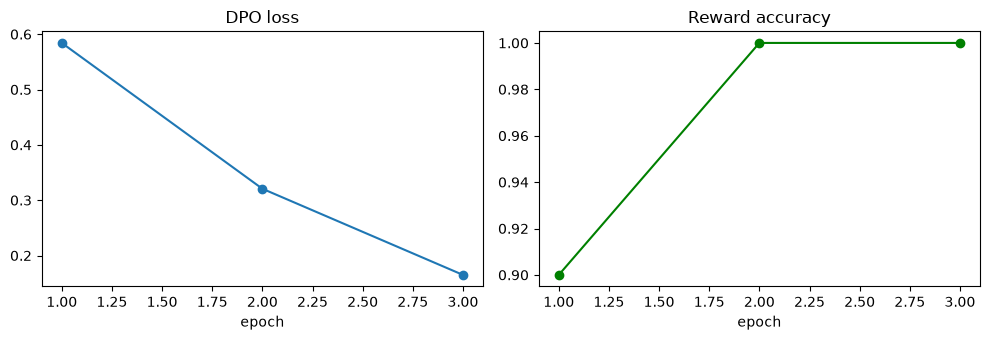

In [10]:
import matplotlib.pyplot as plt
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(h["epoch"], h["loss"], marker="o"); ax[0].set_title("DPO loss"); ax[0].set_xlabel("epoch")
ax[1].plot(h["epoch"], h["reward_accuracy"], marker="o", color="green"); ax[1].set_title("Reward accuracy"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

In [11]:
model.eval()
after = {}
for q in test_questions:
    after[q] = generate(model, q)
    print("Q:", q)
    print("AFTER DPO:\n", after[q])
    print("-" * 80)

Q: What is a neural network?
AFTER DPO:
 A neural network, also known as an artificial neural network or deep learning model, is a type of machine learning algorithm that uses mathematical models to simulate the behavior of complex systems, such as human brains and biological networks. It's designed to learn patterns and relationships in data by adjusting parameters based on input inputs.

In essence, a neural network consists of layers of interconnected nodes (neurons) that process and transmit information. Each node has a set of weights and biases assigned to it, which determine its output value. The network learns by analyzing the data and updating these weights and biases using backpropagation, a technique used to minimize the error between predicted outputs and actual values.

Neural networks can be applied to various tasks, including image recognition
--------------------------------------------------------------------------------
Q: Explain the difference between DNA and RNA.
AF

In [12]:
for q in test_questions:
    print("=" * 90)
    print("QUESTION:", q)
    print("\n--- BEFORE DPO ---\n" + before[q])
    print("\n--- AFTER DPO ---\n" + after[q])

QUESTION: What is a neural network?

--- BEFORE DPO ---
A neural network, also known as an artificial neural network or deep learning model, is a type of machine learning algorithm that uses mathematical models to simulate the behavior of complex systems, such as human brains and biological networks. It's inspired by the structure and function of the brain, which has been extensively studied in neuroscience and computer science.

Neural networks consist of layers of interconnected nodes (also called neurons) that process information and make predictions based on patterns learned from data. These nodes work together to learn and improve over time, allowing them to recognize patterns and make decisions.

The basic components of a neural network include:

1. Neurons: These are the basic units of the network, responsible for processing information.
2. Input

--- AFTER DPO ---
A neural network, also known as an artificial neural network or deep learning model, is a type of machine learning 

In [13]:
def style_metrics(text):
    return {
        "words": len(text.split()),
        "numbered_points": len(re.findall(r"^\s*\d+[\.\)]", text, flags=re.M)),
        "has_definition": int("definition" in text.lower()),
        "has_key_points": int("key points" in text.lower()),
        "has_example": int("example" in text.lower()),
    }

rows = []
for q in test_questions:
    for stage, d in [("Before DPO", before), ("After DPO", after)]:
        rows.append({"question": q, "stage": stage, **style_metrics(d[q])})
metrics = pd.DataFrame(rows)
summary = metrics.drop(columns="question").groupby("stage").mean().round(2).loc[["Before DPO", "After DPO"]]
print(summary.to_string())
summary

             words  numbered_points  has_definition  has_key_points  has_example
stage                                                                           
Before DPO  105.75             0.50             0.0             0.0         0.25
After DPO   117.00             0.75             0.0             0.0         0.25


,words,numbered_points,has_definition,has_key_points,has_example
stage,,,,,
Before DPO,105.75,0.50,0.0,0.0,0.25
After DPO,117.00,0.75,0.0,0.0,0.25


In [14]:
b, a = summary.loc["Before DPO"], summary.loc["After DPO"]
print("Observed changes after DPO:")
print(f"- Numbered points per answer : {b['numbered_points']} -> {a['numbered_points']}")
print(f"- Answers with a definition  : {b['has_definition']*100:.0f}% -> {a['has_definition']*100:.0f}%")
print(f"- Answers with key points    : {b['has_key_points']*100:.0f}% -> {a['has_key_points']*100:.0f}%")
print(f"- Answers with an example    : {b['has_example']*100:.0f}% -> {a['has_example']*100:.0f}%")
print(f"- Average length (words)     : {b['words']} -> {a['words']}")
improved = (a["has_definition"] + a["has_key_points"] + a["has_example"]) > (b["has_definition"] + b["has_key_points"] + b["has_example"])
print("\nConclusion:", "DPO shifted the model towards the preferred style (Definition -> Key points -> Example), "
      "i.e. more structured, student-friendly answers." if improved else
      "The style shift is small; try more epochs, more pairs or a higher learning rate.")

Observed changes after DPO:
- Numbered points per answer : 0.5 -> 0.75
- Answers with a definition  : 0% -> 0%
- Answers with key points    : 0% -> 0%
- Answers with an example    : 25% -> 25%
- Average length (words)     : 105.75 -> 117.0

Conclusion: The style shift is small; try more epochs, more pairs or a higher learning rate.


In [15]:
model.save_pretrained("llama_dpo_adapter")
tokenizer.save_pretrained("llama_dpo_adapter")
print("Saved to ./llama_dpo_adapter")

Saved to ./llama_dpo_adapter
